In [1]:
%pip install --upgrade typing_extensions xgboost

In [2]:
# Cell 1 — Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [5]:
# Cell 2 — Load dataset
df = pd.read_csv(r'D:\House Price Prediction\house-price-prediction\data\train.csv')

print("✅ Data loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

✅ Data loaded successfully!

Shape: (1460, 81)
Rows: 1460
Columns: 81


In [6]:
# Cell 3 — First look at data
print("First 5 rows:")
df.head()

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
# Cell 4 — Understanding columns
print("All Columns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes.value_counts())

print("\nBasic Statistics:")
df.describe()

All Columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolAr

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


House Sale Price Statistics:
Minimum Price  : ₹34,900
Maximum Price  : ₹755,000
Average Price  : ₹180,921
Median Price   : ₹163,000


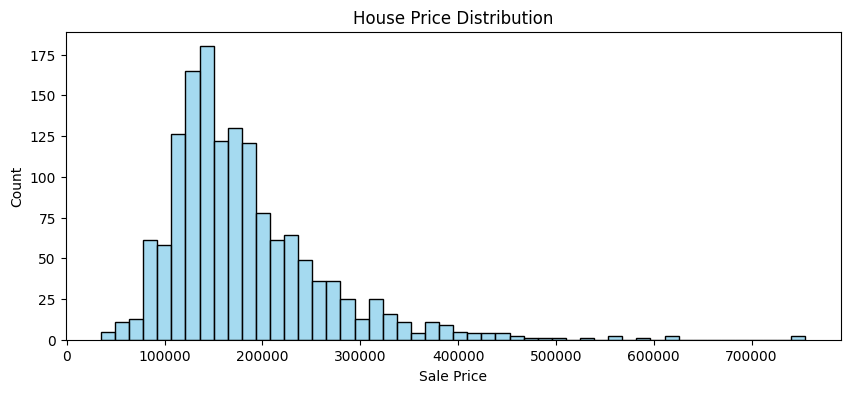

In [8]:
# Cell 5 — Look at what we are predicting
print("House Sale Price Statistics:")
print(f"Minimum Price  : ₹{df['SalePrice'].min():,}")
print(f"Maximum Price  : ₹{df['SalePrice'].max():,}")
print(f"Average Price  : ₹{df['SalePrice'].mean():,.0f}")
print(f"Median Price   : ₹{df['SalePrice'].median():,.0f}")

plt.figure(figsize=(10, 4))
sns.histplot(df['SalePrice'], bins=50, color='skyblue')
plt.title('House Price Distribution')
plt.xlabel('Sale Price')
plt.ylabel('Count')
plt.savefig('../images/price_distribution.png')
plt.show()

In [9]:
# Cell 6 — Find missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percent': missing_percent
}).sort_values('Missing Percent', ascending=False)

# Show only columns with missing values
print("Columns with Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

Columns with Missing Values:
              Missing Count  Missing Percent
PoolQC                 1453        99.520548
MiscFeature            1406        96.301370
Alley                  1369        93.767123
Fence                  1179        80.753425
MasVnrType              872        59.726027
FireplaceQu             690        47.260274
LotFrontage             259        17.739726
GarageYrBlt              81         5.547945
GarageCond               81         5.547945
GarageType               81         5.547945
GarageFinish             81         5.547945
GarageQual               81         5.547945
BsmtFinType2             38         2.602740
BsmtExposure             38         2.602740
BsmtQual                 37         2.534247
BsmtCond                 37         2.534247
BsmtFinType1             37         2.534247
MasVnrArea                8         0.547945
Electrical                1         0.068493


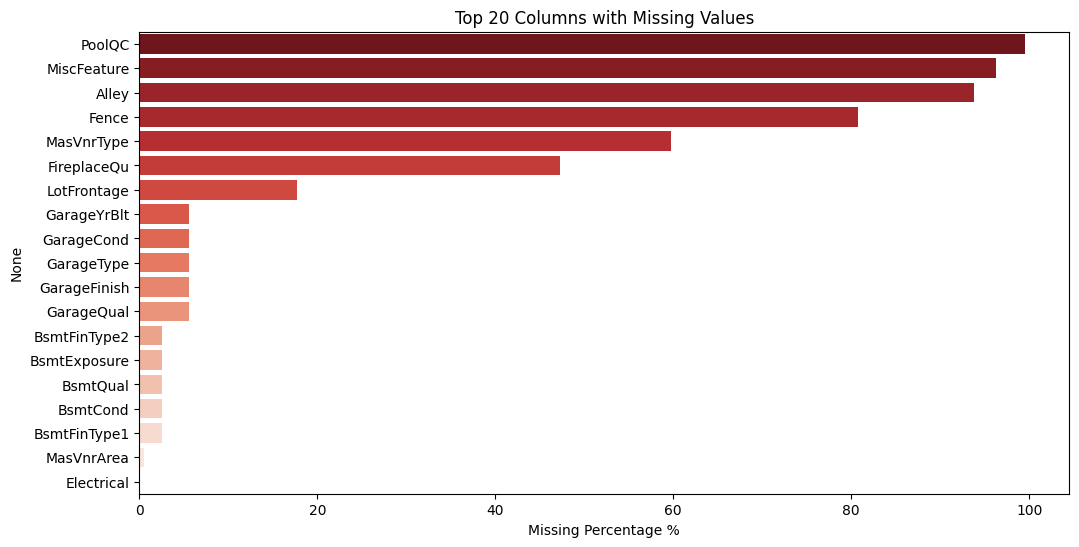

In [10]:
# Cell 7 — Visualize missing data
plt.figure(figsize=(12, 6))
top_missing = missing_df[missing_df['Missing Count'] > 0].head(20)
sns.barplot(x=top_missing['Missing Percent'],
            y=top_missing.index,
            palette='Reds_r')
plt.title('Top 20 Columns with Missing Values')
plt.xlabel('Missing Percentage %')
plt.savefig('../images/missing_values.png')
plt.show()

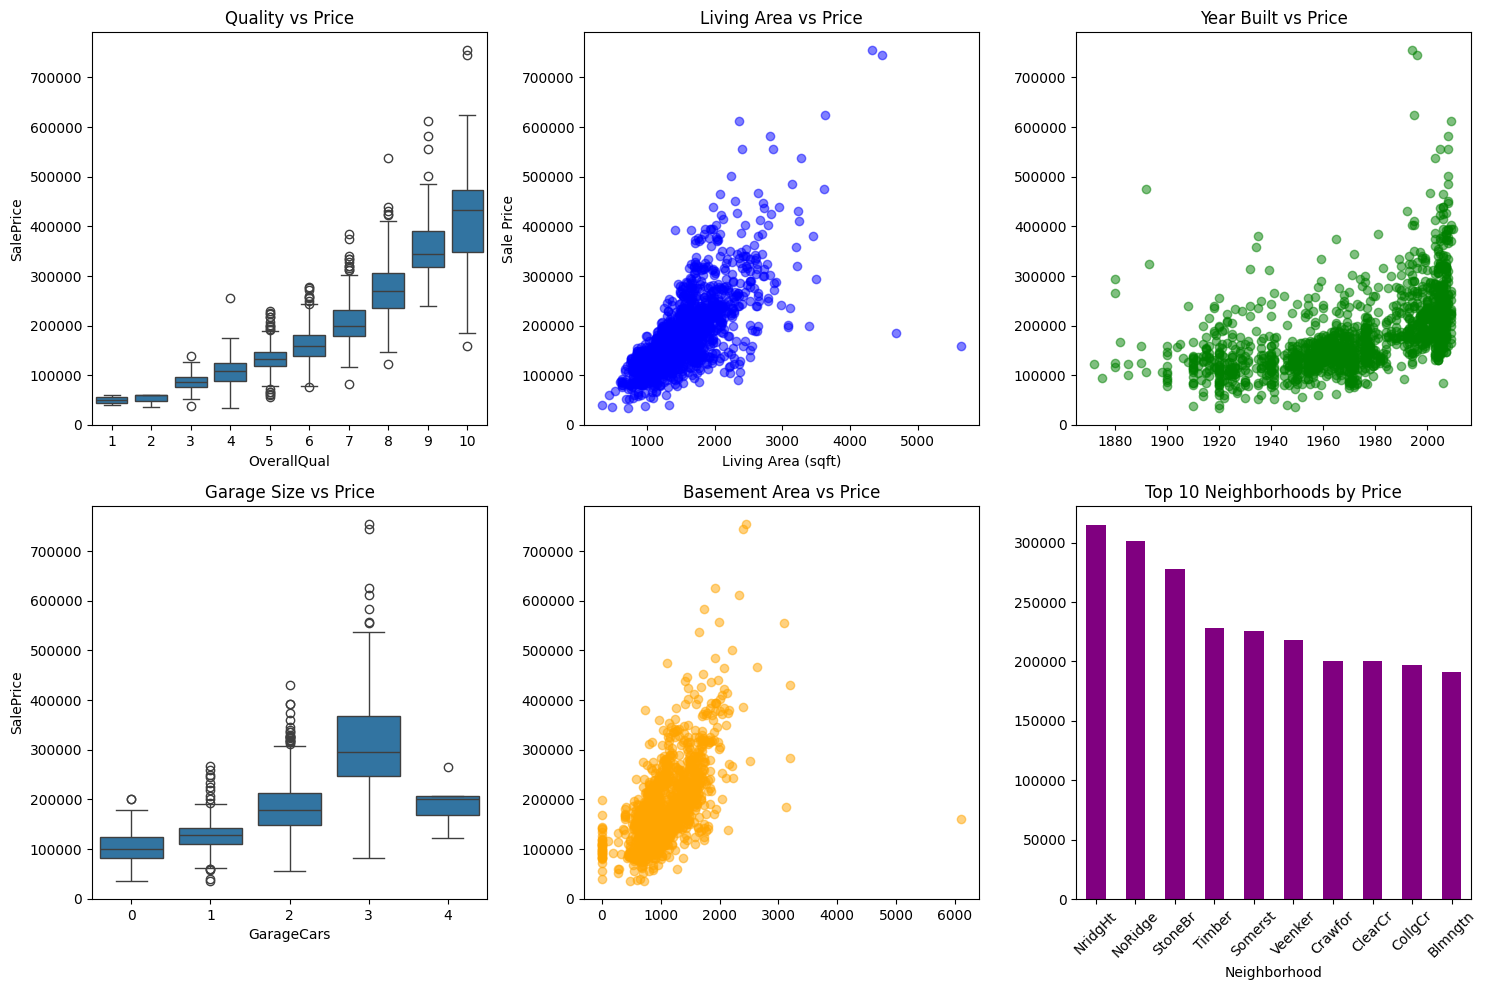

In [12]:
# Cell 8 — What affects house price most?
plt.figure(figsize=(15, 10))

# Chart 1 — Overall Quality vs Price
plt.subplot(2, 3, 1)
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title('Quality vs Price')

# Chart 2 — Living Area vs Price
plt.subplot(2, 3, 2)
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='blue')
plt.title('Living Area vs Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Sale Price')

# Chart 3 — Year Built vs Price
plt.subplot(2, 3, 3)
plt.scatter(df['YearBuilt'], df['SalePrice'], alpha=0.5, color='green')
plt.title('Year Built vs Price')

# Chart 4 — Garage Cars vs Price
plt.subplot(2, 3, 4)
sns.boxplot(x='GarageCars', y='SalePrice', data=df)
plt.title('Garage Size vs Price')

# Chart 5 — Basement Area vs Price
plt.subplot(2, 3, 5)
plt.scatter(df['TotalBsmtSF'], df['SalePrice'], alpha=0.5, color='orange')
plt.title('Basement Area vs Price')

# Chart 6 — Price by Neighborhood
plt.subplot(2, 3, 6)
neighborhood_price = df.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(10)
neighborhood_price.plot(kind='bar', color='purple')
plt.title('Top 10 Neighborhoods by Price')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('../images/eda_charts.png')
plt.show()

In [13]:
# Cell 9 — Clean missing values
df_clean = df.copy()

# Columns where missing means "None/No feature"
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence',
             'FireplaceQu', 'GarageType', 'GarageFinish',
             'GarageQual', 'GarageCond', 'BsmtQual',
             'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
             'BsmtFinType2', 'MasVnrType']

for col in none_cols:
    df_clean[col].fillna('None', inplace=True)

print(f"✅ None columns filled: {len(none_cols)}")

# Columns where missing means 0
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars',
             'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
             'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath',
             'MasVnrArea']

for col in zero_cols:
    df_clean[col].fillna(0, inplace=True)

print(f"✅ Zero columns filled: {len(zero_cols)}")

# Fill numeric with median
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

print("✅ Numeric columns filled with median")

# Fill categorical with mode
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

print("✅ Categorical columns filled with mode")

# Verify
print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")

✅ None columns filled: 15
✅ Zero columns filled: 10
✅ Numeric columns filled with median
✅ Categorical columns filled with mode

Missing values remaining: 0


In [14]:
# Cell 10 — Feature Engineering
df_feat = df_clean.copy()

# Feature 1 — Total Area
df_feat['TotalSF'] = (df_feat['TotalBsmtSF'] +
                      df_feat['1stFlrSF'] +
                      df_feat['2ndFlrSF'])
print("✅ TotalSF created")

# Feature 2 — Total Bathrooms
df_feat['TotalBath'] = (df_feat['FullBath'] +
                        df_feat['HalfBath'] * 0.5 +
                        df_feat['BsmtFullBath'] +
                        df_feat['BsmtHalfBath'] * 0.5)
print("✅ TotalBath created")

# Feature 3 — House Age
df_feat['HouseAge'] = df_feat['YrSold'] - df_feat['YearBuilt']
print("✅ HouseAge created")

# Feature 4 — Remodel Age
df_feat['RemodelAge'] = df_feat['YrSold'] - df_feat['YearRemodAdd']
print("✅ RemodelAge created")

# Feature 5 — Has Pool
df_feat['HasPool'] = (df_feat['PoolArea'] > 0).astype(int)
print("✅ HasPool created")

# Feature 6 — Has Garage
df_feat['HasGarage'] = (df_feat['GarageArea'] > 0).astype(int)
print("✅ HasGarage created")

# Feature 7 — Has Basement
df_feat['HasBasement'] = (df_feat['TotalBsmtSF'] > 0).astype(int)
print("✅ HasBasement created")

print(f"\nTotal features now: {df_feat.shape[1]}")

✅ TotalSF created
✅ TotalBath created
✅ HouseAge created
✅ RemodelAge created
✅ HasPool created
✅ HasGarage created
✅ HasBasement created

Total features now: 88


In [15]:
# Cell 11 — Convert text to numbers
df_encoded = df_feat.copy()

# Label encode all categorical columns
le = LabelEncoder()
cat_cols = df_encoded.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print(f"✅ Encoded {len(cat_cols)} categorical columns")

# Drop ID column
df_encoded.drop('Id', axis=1, inplace=True)

# Prepare X and y
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nReady for ML! ✅")

✅ Encoded 43 categorical columns

Features: 86
Samples: 1460

Ready for ML! ✅


In [16]:
# Cell 12 — Build ML Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Function to evaluate model
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name}:")
    print(f"  RMSE  : ${rmse:,.0f}")
    print(f"  R²    : {r2:.4f}")
    print()
    return model, rmse, r2

# Test all models
print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)

lr_model, lr_rmse, lr_r2 = evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, X_test, y_train, y_test
)

ridge_model, ridge_rmse, ridge_r2 = evaluate_model(
    "Ridge Regression",
    Ridge(alpha=1.0),
    X_train, X_test, y_train, y_test
)

rf_model, rf_rmse, rf_r2 = evaluate_model(
    "Random Forest",
    RandomForestRegressor(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test
)

xgb_model, xgb_rmse, xgb_r2 = evaluate_model(
    "XGBoost",
    xgb.XGBRegressor(n_estimators=500,
                     learning_rate=0.05,
                     max_depth=5,
                     random_state=42),
    X_train, X_test, y_train, y_test
)

MODEL COMPARISON
Linear Regression:
  RMSE  : $38,278
  R²    : 0.8090

Ridge Regression:
  RMSE  : $34,439
  R²    : 0.8454

Random Forest:
  RMSE  : $29,646
  R²    : 0.8854

XGBoost:
  RMSE  : $25,615
  R²    : 0.9145



In [17]:
# Cell 13 — Tune XGBoost for best accuracy
best_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    early_stopping_rounds=50,
    random_state=42
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

final_pred = best_model.predict(X_test)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print(f"✅ Final Tuned XGBoost:")
print(f"   RMSE : ${final_rmse:,.0f}")
print(f"   R²   : {final_r2:.4f}")

[0]	validation_0-rmse:85546.62146
[100]	validation_0-rmse:28647.47283
[200]	validation_0-rmse:25734.54818
[300]	validation_0-rmse:24983.25668
[400]	validation_0-rmse:24689.66414
[500]	validation_0-rmse:24542.11509
[600]	validation_0-rmse:24423.02000
[700]	validation_0-rmse:24379.57510
[757]	validation_0-rmse:24415.54748
✅ Final Tuned XGBoost:
   RMSE : $24,367
   R²   : 0.9226


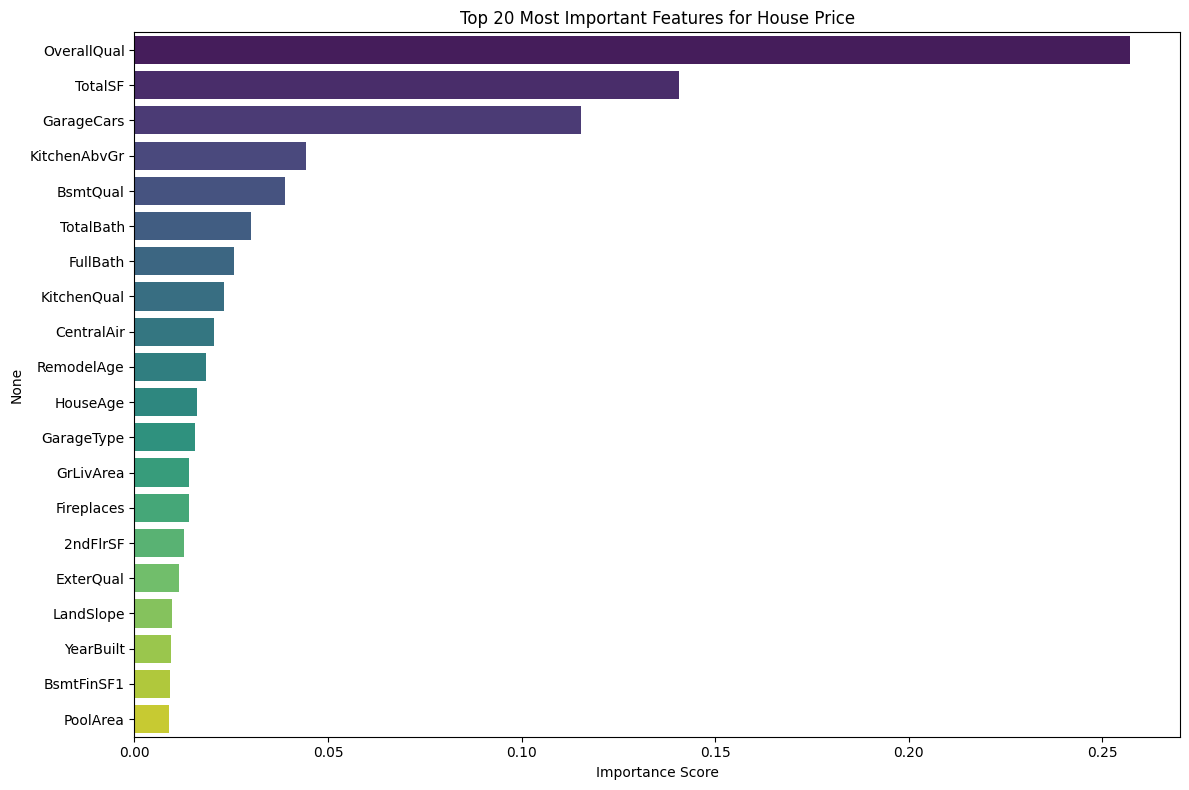

In [18]:
# Cell 14 — Which features matter most?
plt.figure(figsize=(12, 8))
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(20)

sns.barplot(x=feat_imp.values,
            y=feat_imp.index,
            palette='viridis')
plt.title('Top 20 Most Important Features for House Price')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/feature_importance.png')
plt.show()

In [19]:
# Cell 15 — Save everything
import pickle

# Save model
pickle.dump(best_model, open('../outputs/house_price_model.pkl', 'wb'))
print("✅ Model saved!")

# Save predictions
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': final_pred,
    'Difference': abs(y_test.values - final_pred)
})
results.to_csv('../outputs/predictions.csv', index=False)
print("✅ Predictions saved!")

# Final Summary
print("\n" + "="*40)
print("PROJECT SUMMARY")
print("="*40)
print(f"Total Features Used  : {X.shape[1]}")
print(f"Training Samples     : {X_train.shape[0]}")
print(f"Testing Samples      : {X_test.shape[0]}")
print(f"Best Model           : XGBoost")
print(f"Final RMSE           : ${final_rmse:,.0f}")
print(f"Final R² Score       : {final_r2:.4f}")
print(f"Model Accuracy       : {final_r2*100:.2f}%")
print("="*40)

✅ Model saved!
✅ Predictions saved!

PROJECT SUMMARY
Total Features Used  : 86
Training Samples     : 1168
Testing Samples      : 292
Best Model           : XGBoost
Final RMSE           : $24,367
Final R² Score       : 0.9226
Model Accuracy       : 92.26%
